Original Equation: y = 2.5x + 1.2
Custom Results:   y = 2.4891x + 1.1371
Numpy Results:    y = 2.4891x + 1.1371
------------------------------
Largest Residual:  1.0442 at X=0.69
Smallest Residual: 0.0170 at X=0.89


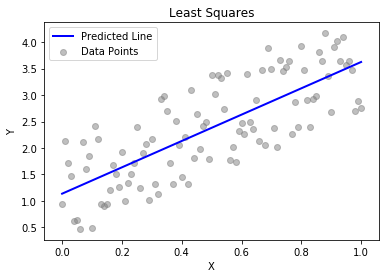

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
mreal, breal = 2.5, 1.2
X = np.arange(0, 1.01, 0.01)
noise = np.random.uniform(-1, 1, size=len(X))
Y = mreal * X + breal + noise

def least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x**2)
    
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    b = (sum_y - m * sum_x) / n
    return m, b

mcustom, bcustom = least_squares(X, Y)

m_numpy, b_numpy = np.polyfit(X, Y, 1)


Y_pred = mcustom * X + bcustom
residuals = np.abs(Y - Y_pred)

idx_max = np.argmax(residuals)
idx_min = np.argmin(residuals)

# 5. Output Results
print(f"Original Equation: y = {mreal}x + {breal}")
print(f"Custom Results:   y = {mcustom:.4f}x + {bcustom:.4f}")
print(f"Numpy Results:    y = {m_numpy:.4f}x + {b_numpy:.4f}")
print("-" * 30)
print(f"Largest Residual:  {residuals[idx_max]:.4f} at X={X[idx_max]:.2f}")
print(f"Smallest Residual: {residuals[idx_min]:.4f} at X={X[idx_min]:.2f}")

# 6. Plotting
plt.scatter(X, Y, color='gray', alpha=0.5, label='Data Points')
plt.plot(X, Y_pred, color='blue', linewidth=2, label='Predicted Line')
plt.title("Least Squares")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()